# Part I: Sample Description & ESG Distribution
Industry Classification: Fama-French 48

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

final_panel = pd.read_csv('esg_financial_panel_2013_2023.csv')
final_panel['datadate'] = pd.to_datetime(final_panel['datadate'])
final_panel['sic'] = pd.to_numeric(final_panel['sic'], errors='coerce')
print(f'Loaded: {len(final_panel):,} firm-year observations')

Loaded: 20,758 firm-year observations


## 1. Fama-French 48 Industry Classification

In [10]:
# Official Fama-French 48 industry definitions
# Source: https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/Data_Library/det_48_ind_port.html
FF48 = [
    (1,  'Agriculture',         [(100,199),(200,299),(700,799),(910,919),(2048,2048)]),
    (2,  'Food Products',       [(2000,2046),(2050,2063),(2070,2079),(2086,2086),(2090,2092),(2095,2095),(2096,2096),(2097,2099)]),
    (3,  'Candy & Soda',        [(2064,2068),(2086,2086),(2096,2096),(2097,2097)]),
    (4,  'Beer & Liquor',       [(2080,2085),(2080,2080)]),
    (5,  'Tobacco Products',    [(2100,2199)]),
    (6,  'Recreation',          [(7800,7833),(7840,7841),(7900,7999),(7993,7993),(7997,7997)]),
    (7,  'Entertainment',       [(7812,7819),(7820,7823),(7824,7829)]),
    (8,  'Printing & Publishing',[(2700,2749),(2770,2771),(2780,2799)]),
    (9,  'Consumer Goods',      [(2047,2047),(2391,2392),(2510,2519),(2590,2599),(2840,2844),(2846,2849),(3160,3162),(3170,3172),(3190,3199),(3229,3229),(3260,3260),(3262,3263),(3269,3269),(3630,3639),(3750,3751),(3800,3800),(3860,3861),(3870,3879),(3910,3919),(3960,3969),(3991,3991),(3995,3995)]),
    (10, 'Apparel',             [(2300,2390),(3020,3021),(3100,3111),(3130,3131),(3140,3149),(3150,3151),(3963,3965)]),
    (11, 'Healthcare',          [(8000,8099)]),
    (12, 'Medical Equipment',   [(3841,3851),(3841,3841),(3842,3842),(3843,3843),(3844,3844),(3845,3845),(3851,3851),(5047,5047),(5122,5122),(5047,5047)]),
    (13, 'Pharmaceutical Products', [(2830,2836)]),
    (14, 'Chemicals',           [(2800,2829),(2850,2879),(2890,2899)]),
    (15, 'Rubber & Plastic',    [(3000,3030),(3041,3041),(3050,3053),(3060,3069),(3070,3079),(3080,3089),(3090,3099)]),
    (16, 'Textiles',            [(2200,2284),(2290,2295),(2297,2299),(2393,2395),(2397,2399)]),
    (17, 'Construction Materials', [(800,899),(1500,1511),(1520,1542),(1550,1559),(1600,1699),(1711,1799),(2400,2439),(2450,2459),(2490,2499),(2660,2661),(2950,2952),(3200,3200),(3210,3211),(3240,3241),(3250,3259),(3261,3261),(3264,3264),(3270,3275),(3280,3281),(3290,3293),(3295,3299),(3420,3429),(3430,3433),(3440,3441),(3442,3442),(3446,3446),(3448,3448),(3449,3449),(3460,3469),(3490,3499),(3996,3996)]),
    (18, 'Steel Works',         [(3300,3300),(3310,3317),(3320,3325),(3330,3341),(3350,3357),(3360,3369),(3390,3399)]),
    (19, 'Fabricated Products', [(3410,3412),(3443,3443),(3444,3444),(3460,3462),(3490,3492),(3494,3495),(3496,3499)]),
    (20, 'Machinery',           [(3510,3519),(3520,3529),(3530,3530),(3531,3531),(3532,3532),(3533,3533),(3534,3534),(3535,3535),(3536,3536),(3538,3538),(3540,3549),(3550,3559),(3560,3569),(3580,3580),(3581,3581),(3582,3582),(3585,3585),(3586,3586),(3589,3589),(3590,3599)]),
    (21, 'Electrical Equipment',[(3600,3600),(3610,3613),(3620,3621),(3623,3629),(3640,3646),(3648,3649),(3660,3660),(3690,3692),(3699,3699)]),
    (22, 'Automobiles & Trucks',[(2296,2296),(2396,2396),(3010,3011),(3537,3537),(3647,3647),(3694,3694),(3700,3700),(3710,3710),(3711,3711),(3713,3713),(3714,3714),(3715,3715),(3716,3716),(3750,3750),(3751,3751),(3792,3792),(3790,3791),(3799,3799)]),
    (23, 'Aircraft',            [(3720,3720),(3721,3721),(3723,3724),(3725,3725),(3728,3729)]),
    (24, 'Shipbuilding',        [(3730,3731),(3740,3743)]),
    (25, 'Defense',             [(3760,3769),(3489,3489),(3480,3489),(3812,3812)]),
    (26, 'Precious Metals',     [(1040,1049)]),
    (27, 'Non-Metallic Mining', [(1000,1039),(1050,1099),(1400,1499)]),
    (28, 'Coal',                [(1200,1299)]),
    (29, 'Petroleum & Natural Gas', [(1300,1399),(2900,2912),(2990,2999)]),
    (30, 'Utilities',           [(4900,4900),(4910,4911),(4920,4922),(4923,4923),(4924,4925),(4930,4932),(4939,4942),(4950,4952),(4953,4953),(4959,4959),(4961,4961),(4991,4991)]),
    (31, 'Communication',       [(4800,4800),(4810,4813),(4820,4822),(4830,4839),(4840,4841),(4880,4889),(4890,4891),(4892,4892),(4895,4895),(4899,4899)]),
    (32, 'Personal Services',   [(7020,7021),(7040,7041),(7080,7081),(7200,7200),(7210,7212),(7214,7214),(7215,7221),(7230,7231),(7240,7241),(7250,7251),(7260,7269),(7270,7290),(7291,7291),(7292,7299),(7300,7300),(7389,7389),(7395,7395),(7500,7500),(7520,7520),(7521,7521),(7532,7534),(7536,7539),(7600,7600),(7620,7620),(7622,7622),(7623,7623),(7629,7629),(7630,7631),(7640,7641),(7690,7691),(7692,7699),(8200,8299),(8300,8399),(8400,8499),(8600,8699),(8800,8899),(7510,7515)]),
    (33, 'Business Services',   [(7370,7372),(7374,7374),(7375,7375),(7376,7376),(7377,7377),(7378,7378),(7379,7379),(7380,7380),(7381,7382),(7383,7384),(7385,7389),(7390,7391),(7392,7392),(7393,7393),(7394,7394),(7396,7396),(7397,7397),(7399,7399),(7514,7514),(7515,7515),(7519,7519),(8700,8700),(8710,8713),(8720,8721),(8730,8734),(8740,8742),(8748,8748),(8900,8911),(8920,8999),(4220,4229)]),
    (34, 'Computers',           [(3570,3579),(3680,3680),(3681,3681),(3682,3682),(3683,3683),(3684,3684),(3685,3685),(3686,3686),(3687,3687),(3688,3688),(3689,3689),(3695,3695),(7373,7373)]),
    (35, 'Electronic Equipment',[(3622,3622),(3661,3661),(3662,3662),(3663,3663),(3664,3664),(3665,3665),(3666,3666),(3669,3669),(3670,3679),(3810,3810),(3812,3812)]),
    (36, 'Measuring Instruments',[(3811,3811),(3820,3820),(3821,3821),(3822,3822),(3823,3823),(3824,3824),(3825,3825),(3826,3826),(3827,3827),(3829,3829),(3830,3839)]),
    (37, 'Misc. Business',      [(3900,3900),(3910,3911),(3914,3914),(3915,3915),(3920,3921),(3922,3922),(3931,3931),(3940,3944),(3945,3945),(3946,3946),(3947,3947),(3948,3949),(3950,3955),(3960,3962),(3970,3979),(3980,3980),(3981,3987),(3988,3989),(3990,3990),(3991,3991),(3993,3993),(3994,3994),(3995,3995),(3996,3996),(3997,3997),(3999,3999)]),
    (38, 'Transportation',      [(4000,4013),(4040,4049),(4100,4100),(4110,4121),(4130,4131),(4140,4142),(4150,4151),(4170,4173),(4190,4200),(4210,4219),(4220,4221),(4230,4231),(4240,4249),(4400,4412),(4420,4429),(4430,4439),(4440,4449),(4450,4459),(4460,4469),(4470,4479),(4480,4489),(4490,4499),(4600,4612),(4620,4621),(4700,4700),(4710,4712),(4720,4729),(4730,4739),(4740,4742),(4750,4757),(4760,4761),(4770,4779),(4780,4780),(4782,4782),(4783,4783),(4784,4784),(4785,4785),(4789,4789)]),
    (39, 'Wholesale',           [(5000,5000),(5010,5015),(5020,5023),(5030,5039),(5040,5042),(5043,5043),(5044,5044),(5045,5045),(5046,5046),(5047,5047),(5048,5049),(5050,5052),(5060,5065),(5070,5078),(5080,5088),(5090,5090),(5091,5092),(5094,5099),(5100,5100),(5110,5113),(5120,5122),(5130,5139),(5140,5149),(5150,5159),(5160,5169),(5170,5172),(5180,5182),(5190,5199)]),
    (40, 'Retail',              [(5200,5200),(5210,5211),(5220,5221),(5230,5231),(5250,5251),(5260,5261),(5270,5271),(5300,5300),(5310,5311),(5320,5321),(5330,5331),(5334,5334),(5340,5349),(5390,5399),(5400,5400),(5410,5411),(5412,5412),(5420,5421),(5430,5431),(5440,5441),(5450,5451),(5460,5462),(5490,5499),(5500,5500),(5510,5511),(5520,5521),(5530,5531),(5540,5541),(5550,5551),(5560,5561),(5570,5571),(5580,5581),(5590,5599),(5600,5600),(5610,5611),(5620,5621),(5630,5631),(5640,5641),(5650,5651),(5660,5661),(5670,5671),(5680,5681),(5690,5699),(5700,5700),(5710,5712),(5713,5713),(5714,5714),(5715,5715),(5719,5719),(5720,5722),(5730,5736),(5750,5750),(5751,5751),(5760,5765),(5770,5771),(5780,5781),(5790,5799),(5900,5900),(5910,5912),(5920,5929),(5930,5932),(5940,5949),(5950,5959),(5960,5969),(5970,5979),(5980,5989),(5990,5999)]),
    (41, 'Restaurants & Hotels',[(5800,5819),(5820,5829),(5890,5899),(7000,7011),(7041,7041),(7900,7900),(7010,7019)]),
    (42, 'Banking',             [(6000,6000),(6010,6011),(6020,6029),(6030,6036),(6040,6062),(6080,6082),(6090,6099),(6110,6111),(6112,6113),(6120,6129),(6130,6139),(6140,6149),(6150,6159),(6160,6169),(6170,6179),(6190,6199)]),
    (43, 'Insurance',           [(6300,6300),(6310,6311),(6320,6321),(6324,6324),(6330,6331),(6350,6351),(6360,6361),(6370,6371),(6390,6399),(6411,6411)]),
    (44, 'Real Estate',         [(6500,6500),(6510,6512),(6513,6513),(6514,6514),(6515,6515),(6512,6512),(6552,6553),(6798,6798)]),
    (45, 'Trading',             [(6200,6299),(6710,6726),(6730,6733),(6740,6779),(6790,6791),(6792,6792),(6794,6794),(6795,6795),(6798,6798),(6726,6726)]),
]

# Build lookup dict: sic -> (id, name)
sic_to_ff48 = {}
for ff_id, ff_name, ranges in FF48:
    if not ranges:
        continue
    for lo, hi in ranges:
        for s in range(lo, hi+1):
            if s not in sic_to_ff48:   # first match wins
                sic_to_ff48[s] = (ff_id, ff_name)

def assign_ff48(sic):
    if pd.isna(sic):
        return (48, 'Other')
    s = int(sic)
    return sic_to_ff48.get(s, (48, 'Other'))

ff48_result = final_panel['sic'].apply(assign_ff48)
final_panel['ff48_id']   = ff48_result.apply(lambda x: x[0])
final_panel['industry']  = ff48_result.apply(lambda x: x[1])

print(f'Other (unclassified): {(final_panel["industry"]=="Other").sum():,} ({(final_panel["industry"]=="Other").mean()*100:.1f}%)')
print('\nTop 15 industries by count:')
print(final_panel['industry'].value_counts().head(15).to_string())

Other (unclassified): 1,040 (5.0%)

Top 15 industries by count:
industry
Banking                    2662
Pharmaceutical Products    2061
Business Services          1985
Other                      1040
Retail                      901
Electronic Equipment        812
Insurance                   782
Medical Equipment           746
Utilities                   730
Petroleum & Natural Gas     666
Construction Materials      654
Machinery                   628
Trading                     573
Wholesale                   529
Chemicals                   448


## 2. Table 1: Summary Statistics

In [11]:
vars_stats = ['esg_score','roa','future_roa','future_annual_ret',
              'at','size','lag_roa','lag_size']

def winsorize_series(s, lower=0.01, upper=0.99):
    return s.clip(s.quantile(lower), s.quantile(upper))

final_panel['roa'] = winsorize_series(final_panel['roa'])
final_panel['future_roa'] = winsorize_series(final_panel['future_roa'])

final_panel['future_annual_ret'] = winsorize_series(final_panel['future_annual_ret'])

final_panel['esg_score'] = winsorize_series(final_panel['esg_score'])

summary = final_panel[vars_stats].describe().T
summary = summary[['count','mean','std','min','25%','50%','75%','max']]
summary.columns = ['N','Mean','Std','Min','P25','Median','P75','Max']
summary = summary.round(4)

print('Table 1: Summary Statistics')
display(summary)

Table 1: Summary Statistics


,N,Mean,Std,Min,P25,Median,P75,Max
esg_score,20758.0,0.4042,0.1909,0.0697,0.2538,0.3735,0.5387,8.542000e-01
roa,20756.0,-0.0063,0.1701,-0.8335,-0.0056,0.0243,0.0699,2.933000e-01
future_roa,18372.0,-0.0021,0.1652,-0.8149,-0.0028,0.0257,0.0712,2.885000e-01
future_annual_ret,20758.0,0.1291,0.4915,-0.7830,-0.1580,0.0699,0.3219,2.372500e+00
at,20758.0,21082.1380,125632.1814,1.2200,727.2870,2454.4190,8552.9172,3.875393e+06
size,20758.0,7.8705,1.9082,0.1989,6.5893,7.8056,9.0540,1.517020e+01
lag_roa,19438.0,-0.0092,0.2182,-4.8440,-0.0045,0.0244,0.0695,4.023200e+00
lag_size,19443.0,7.7723,1.9227,0.1989,6.4681,7.7103,8.9600,1.513550e+01


Table 1 reports descriptive statistics for the main variables used in the analysis. The mean ESG score is 0.4041 (median 0.3734), with a standard deviation of 0.1909, indicating substantial cross-sectional variation in ESG performance across firms. ESG scores range from 0.0697 to 0.8542, suggesting that while some firms achieve relatively high ESG performance, a significant proportion of firms remain at moderate levels.

Return on assets (ROA) has a mean of –0.0064 and a median of 0.0243. The negative mean alongside a positive median suggests that firm profitability is right-skewed, with a subset of firms experiencing losses that pull down the average. Future ROA shows a similar pattern, with a mean of –0.0022 and a median of 0.0257, indicating persistence in profitability but also continued dispersion across firms.

The average annual stock return is 12.9%, with a median of 6.98% and a standard deviation of 0.492, reflecting substantial variability in firm-level returns. Firm size, measured as the logarithm of total assets, has a mean of 7.87 (median 7.80), corresponding to a median total asset level of approximately $2.45 billion. This suggests that the sample is tilted toward relatively large firms, consistent with the coverage patterns of ESG rating data.

All continuous variables are winsorized at the 1st and 99th percentiles to mitigate the influence of extreme values.

## 3. Table 2: ESG by Industry + Figure 1

Table 2: ESG Score by Industry (FF48, N>=50, sorted by Mean ESG)


,Mean ESG,Median ESG,Std ESG,N
industry,,,,
Precious Metals,0.5179,0.5352,0.2533,52
Utilities,0.5141,0.5342,0.1871,730
Beer & Liquor,0.5125,0.5402,0.1898,65
Chemicals,0.4849,0.4741,0.2121,448
Food Products,0.4755,0.5144,0.2382,398
Measuring Instruments,0.4675,0.4629,0.1954,335
Apparel,0.4658,0.4635,0.1862,228
Restaurants & Hotels,0.4623,0.4468,0.1974,370
Aircraft,0.4619,0.4487,0.1920,126


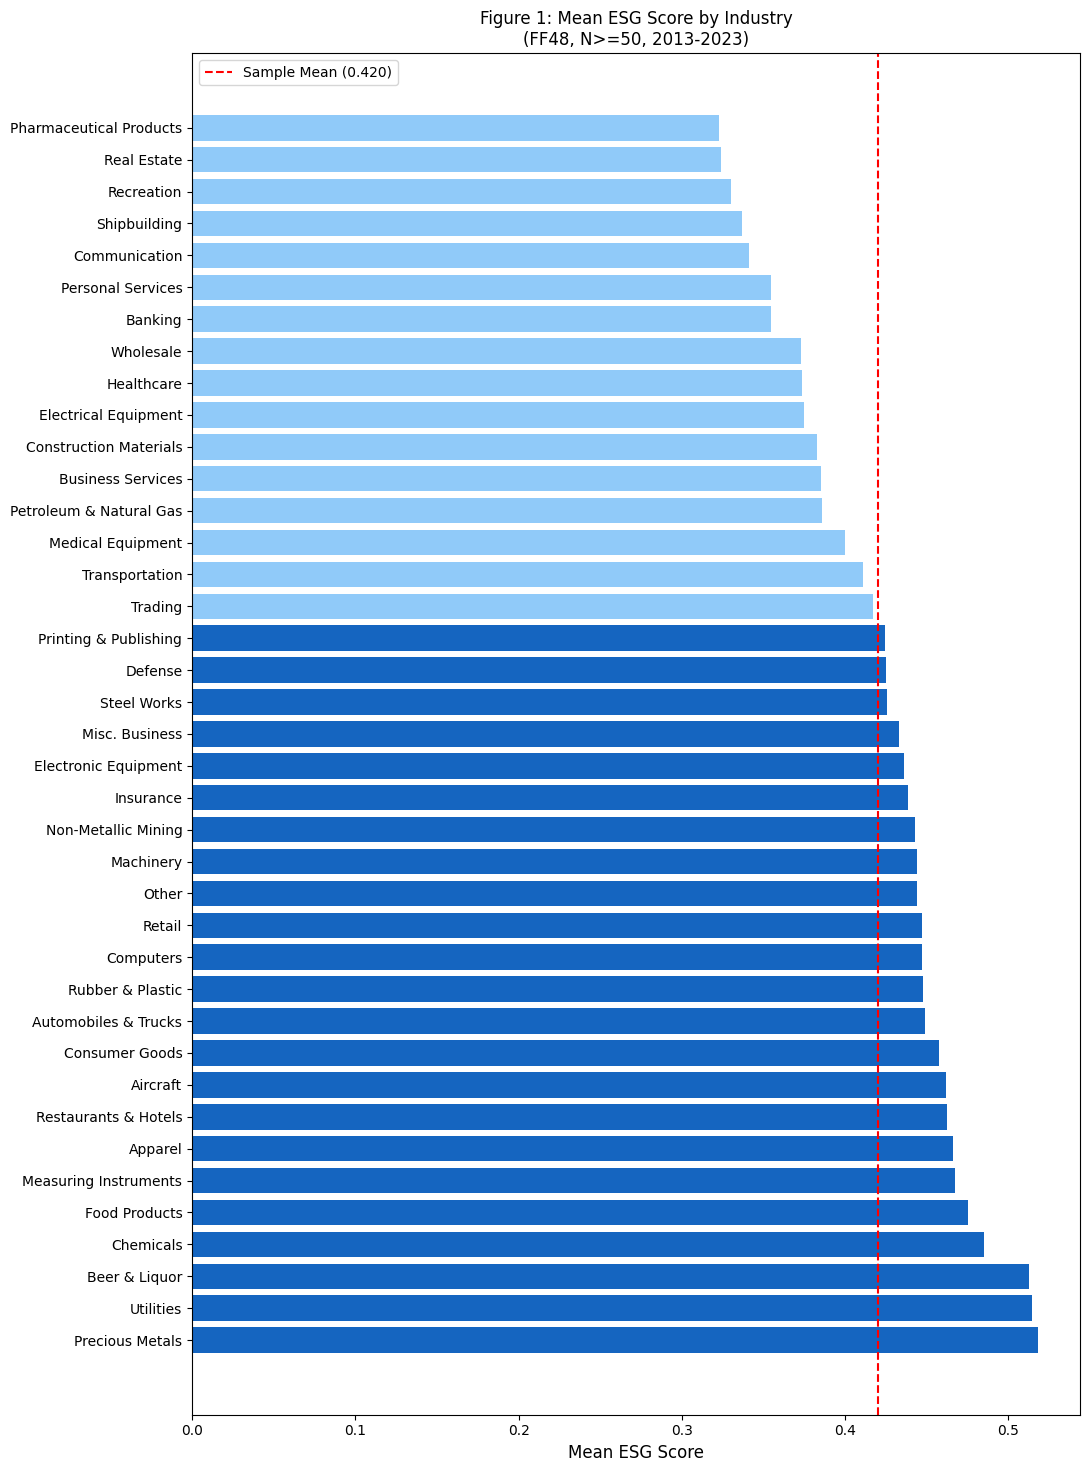

In [12]:
# Only keep industries with N >= 50 to avoid noise
esg_by_ind = (
    final_panel.groupby("industry")["esg_score"]
    .agg(["mean","median","std","count"])
    .rename(columns={"mean":"Mean ESG","median":"Median ESG",
                     "std":"Std ESG","count":"N"})
    .sort_values("Mean ESG", ascending=False)
    .round(4)
)

# Filter N >= 50 for both table and figure
esg_by_ind_full = esg_by_ind.copy()  # keep full version for reference
esg_by_ind = esg_by_ind[esg_by_ind["N"] >= 50].copy()

print("Table 2: ESG Score by Industry (FF48, N>=50, sorted by Mean ESG)")
display(esg_by_ind)

# Figure 1: bar chart
sample_mean = esg_by_ind["Mean ESG"].mean()
colors = ["#1565C0" if v >= sample_mean else "#90CAF9"
          for v in esg_by_ind["Mean ESG"]]

fig, ax = plt.subplots(figsize=(11, max(7, len(esg_by_ind)*0.38)))
ax.barh(esg_by_ind.index, esg_by_ind["Mean ESG"], color=colors)
ax.axvline(sample_mean, color="red", linestyle="--", linewidth=1.5,
           label=f"Sample Mean ({sample_mean:.3f})")
ax.set_xlabel("Mean ESG Score", fontsize=12)
ax.set_title("Figure 1: Mean ESG Score by Industry\n(FF48, N>=50, 2013-2023)", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


In [13]:
industry_esg = final_panel.groupby('industry').agg(
    mean_esg=('esg_score', 'mean'),
    median_esg=('esg_score', 'median'),
    n=('esg_score', 'count')
).reset_index()

industry_esg = industry_esg[industry_esg['n'] >= 50]
industry_esg = industry_esg.sort_values(by='mean_esg', ascending=False)

top3 = industry_esg.head(3)
bottom3 = industry_esg.tail(3)

print("Top 3 industries by ESG:")
display(top3)

print("Bottom 3 industries by ESG:")
display(bottom3)

Top 3 industries by ESG:


,industry,mean_esg,median_esg,n
29,Precious Metals,0.517936,0.535196,52
42,Utilities,0.514093,0.534202,730
5,Beer & Liquor,0.512455,0.540246,65


Bottom 3 industries by ESG:


,industry,mean_esg,median_esg,n
32,Recreation,0.330294,0.266501,230
31,Real Estate,0.323703,0.207284,81
28,Pharmaceutical Products,0.322418,0.283708,2061


Table 2 and Figure 1 report mean ESG scores by industry for all industries with at least 50 firm-year observations. There is meaningful variation across industries, with mean scores ranging from 0.322 to 0.520.

Precious Metals (0.5179), Utilities (0.5141), and Beer & Liquor (0.5125) record the highest ESG scores. Precious Metals firms tend to score highly due to strong community engagement requirements and environmental remediation obligations in mining-heavy regions. Utilities firms consistently rank near the top across ESG rating systems, driven by heavy regulatory scrutiny, mandatory environmental disclosures, and long investment horizons that incentivize sustainability planning. The strong performance of Beer & Liquor firms likely reflects the industry's proactive approach to supply chain transparency, water usage reporting, and responsible consumption initiatives.

At the lower end, Pharmaceutical Products (0.3224), Real Estate (0.3237), and Recreation (0.3303) record the lowest scores. The weak performance of Pharmaceutical firms is particularly notable given that it is the second-largest industry group in our sample (2,061 firm-years). Low ESG scores in this sector are often attributed to controversies around drug pricing, patent practices that limit medicine access in developing markets, and lack of transparency in clinical trial reporting. Real Estate firms tend to score poorly due to limited ESG disclosure standards historically applied to the sector, though this is changing with the rise of green building certifications and TCFD reporting.

It is also worth noting that Banking (0.3546) and Business Services (0.3852) — together accounting for over 4,600 firm-years, the two largest industry groups in our sample — both score below the sample average. This suggests that sheer size and market prominence do not translate into stronger ESG performance.

**Note**: Industries with fewer than 50 observations (e.g., Tobacco Products, Coal) are excluded from Table 2 and Figure 1 due to small sample size, but are retained in all other analyses.

## 4. Table 3: ESG Over Time + Figure 2 + Table 4: Top3 & Bottom 3 Industries

Table 3: ESG Score Over Time


,Mean ESG,Median ESG,Std,N Firms
fyear,,,,
2013,0.4375,0.4275,0.1885,745
2014,0.4440,0.4301,0.1849,730
2015,0.3960,0.3654,0.1854,1186
2016,0.3695,0.3303,0.1792,1763
2017,0.3624,0.3250,0.1787,2163
2018,0.3678,0.3290,0.1837,2241
2019,0.3853,0.3522,0.1855,2373
2020,0.4047,0.3752,0.1947,2492
2021,0.4285,0.4057,0.1944,2451


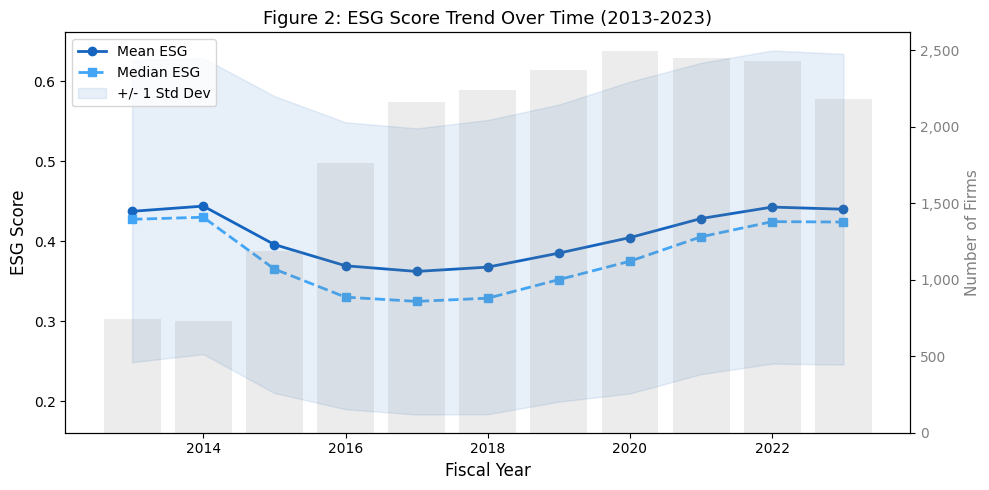

In [14]:
esg_by_year = (
    final_panel.groupby('fyear')['esg_score']
    .agg(['mean','median','std','count'])
    .rename(columns={'mean':'Mean ESG','median':'Median ESG',
                     'std':'Std','count':'N Firms'})
    .round(4)
)

print('Table 3: ESG Score Over Time')
display(esg_by_year)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(esg_by_year.index, esg_by_year['Mean ESG'],
         marker='o', color='#1565C0', linewidth=2, label='Mean ESG')
ax1.plot(esg_by_year.index, esg_by_year['Median ESG'],
         marker='s', color='#42A5F5', linewidth=2,
         linestyle='--', label='Median ESG')
ax1.fill_between(esg_by_year.index,
                 esg_by_year['Mean ESG'] - esg_by_year['Std'],
                 esg_by_year['Mean ESG'] + esg_by_year['Std'],
                 alpha=0.1, color='#1565C0', label='+/- 1 Std Dev')
ax1.set_ylabel('ESG Score', fontsize=12)
ax1.set_xlabel('Fiscal Year', fontsize=12)
ax1.set_title('Figure 2: ESG Score Trend Over Time (2013-2023)', fontsize=13)
ax1.legend(loc='upper left', fontsize=10)

ax2 = ax1.twinx()
ax2.bar(esg_by_year.index, esg_by_year['N Firms'],
        alpha=0.15, color='gray')
ax2.set_ylabel('Number of Firms', fontsize=11, color='gray')
ax2.tick_params(axis='y', labelcolor='gray')
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

Table 3 and Figure 2 document the evolution of ESG scores over the sample period. The data reveal a U-shaped pattern: mean ESG scores begin at around 0.44 in 2013–2014, decline steadily to a trough of 0.3624 in 2017, and then recover consistently to 0.4427 by 2022.

The mid-period decline is partly a sample composition effect. As shown in Figure 4, the number of covered firms grows sharply from approximately 745 in 2013 to over 2,400 by 2019, as Refinitiv expanded its ESG coverage to include smaller and less-established firms that tend to have lower scores. This expansion mechanically depresses the cross-sectional average during the mid-sample years.

The post-2018 recovery, however, reflects more substantive change. It coincides with rising institutional investor pressure on ESG disclosure, the emergence of major regulatory frameworks such as the EU Sustainable Finance Action Plan and the TCFD recommendations, and the broader mainstreaming of ESG as an investment criterion. The consistent increase from 2018 to 2022 suggests that ESG performance and reporting have become increasingly institutionalized across publicly listed firms. Overall, the evidence points to a genuine upward trend in ESG scores over the sample period.  The mid-period decline likely reflects a combination of sample expansion effects and real economic headwinds — including the commodity price crash of 2015–2016 and reduced regulatory pressure following the U.S. withdrawal from the Paris Agreement in 2017 — both of which dampened corporate ESG investment during this period (opinion).

## 5. Figure 3: Heatmap — Top 15 Industries x Year

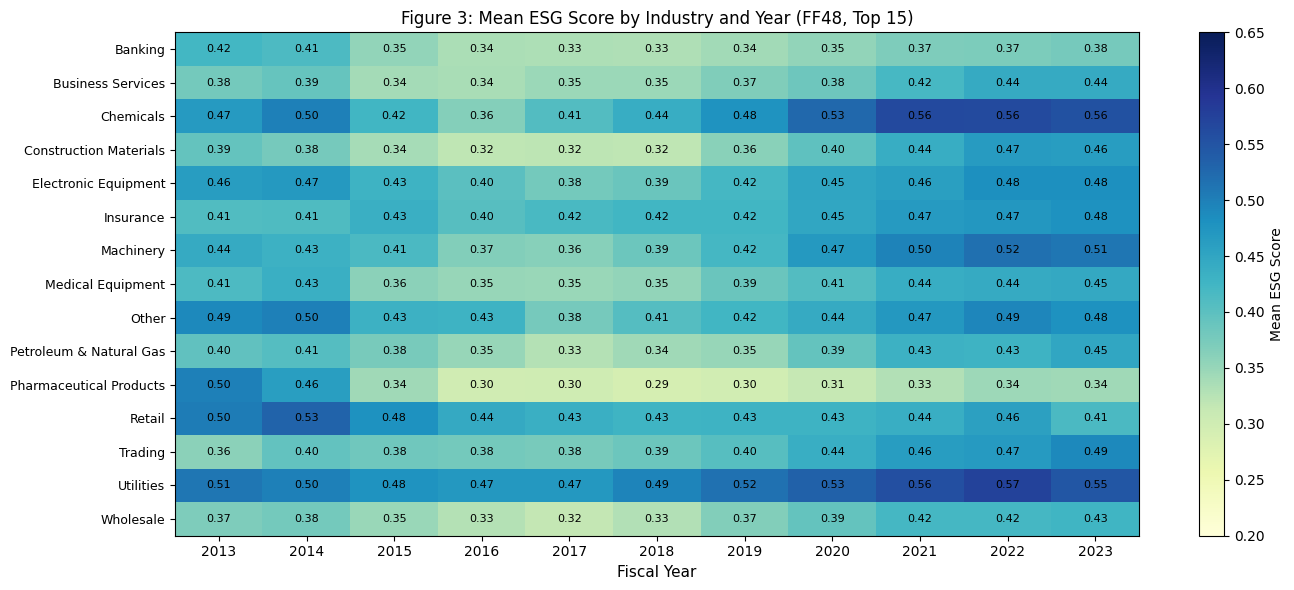

In [15]:
top15 = (
    final_panel.groupby('industry')['gvkey'].count()
    .nlargest(15).index.tolist()
)

esg_pivot = (
    final_panel[final_panel['industry'].isin(top15)]
    .groupby(['fyear','industry'])['esg_score']
    .mean()
    .unstack('industry')
    .round(3)
)

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(esg_pivot.T.values, aspect='auto',
               cmap='YlGnBu', vmin=0.2, vmax=0.65)

ax.set_xticks(range(len(esg_pivot.index)))
ax.set_xticklabels(esg_pivot.index.astype(int), fontsize=10)
ax.set_yticks(range(len(esg_pivot.columns)))
ax.set_yticklabels(esg_pivot.columns, fontsize=9)
ax.set_title('Figure 3: Mean ESG Score by Industry and Year (FF48, Top 15)', fontsize=12)
ax.set_xlabel('Fiscal Year', fontsize=11)

for i in range(len(esg_pivot.columns)):
    for j in range(len(esg_pivot.index)):
        val = esg_pivot.T.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color='black')

plt.colorbar(im, ax=ax, label='Mean ESG Score')
plt.tight_layout()
plt.show()

## 6. Figure 4: Sample Size Over Time + Summary

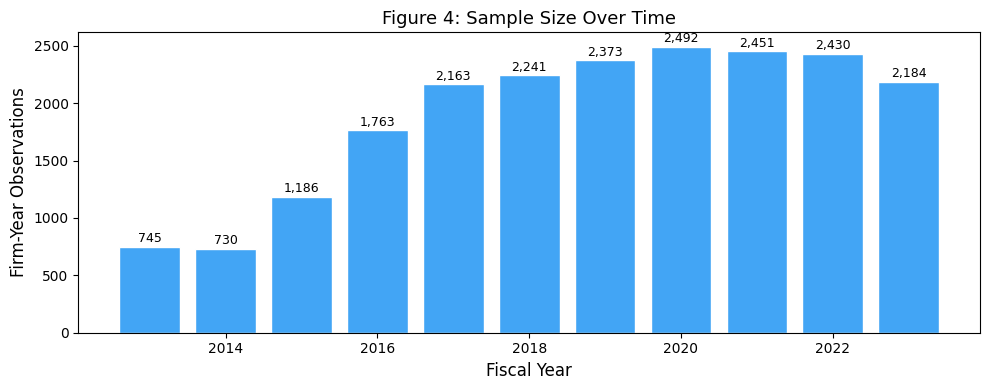

=== Summary ===
Total firm-year obs : 20,758
Unique firms        : 3,350
Years               : 2013 - 2023
Industries (FF48)   : 44
Other (unclassified): 5.0%

Top 5 industries by Mean ESG (N>=50):
industry
Precious Metals    0.5179
Utilities          0.5141
Beer & Liquor      0.5125
Chemicals          0.4849
Food Products      0.4755

Bottom 5 industries by Mean ESG (N>=50):
industry
Communication              0.3412
Shipbuilding               0.3369
Recreation                 0.3303
Real Estate                0.3237
Pharmaceutical Products    0.3224


In [16]:
count_by_year = final_panel.groupby('fyear')['gvkey'].count()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(count_by_year.index, count_by_year.values,
       color='#42A5F5', edgecolor='white')
for x, y in zip(count_by_year.index, count_by_year.values):
    ax.text(x, y + 15, f'{y:,}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Fiscal Year', fontsize=12)
ax.set_ylabel('Firm-Year Observations', fontsize=12)
ax.set_title('Figure 4: Sample Size Over Time', fontsize=13)
plt.tight_layout()
plt.show()

ind_n50 = esg_by_ind[esg_by_ind['N'] >= 50]
print('=== Summary ===')
print(f'Total firm-year obs : {len(final_panel):,}')
print(f'Unique firms        : {final_panel["gvkey"].nunique():,}')
print(f'Years               : {int(final_panel["fyear"].min())} - {int(final_panel["fyear"].max())}')
print(f'Industries (FF48)   : {final_panel["industry"].nunique()}')
print(f'Other (unclassified): {(final_panel["industry"]=="Other").mean()*100:.1f}%')
print(f'\nTop 5 industries by Mean ESG (N>=50):')
print(ind_n50['Mean ESG'].head(5).to_string())
print(f'\nBottom 5 industries by Mean ESG (N>=50):')
print(ind_n50['Mean ESG'].tail(5).to_string())

Based on our analysis, Precious Metals, Utilities, Beer & Liquor, and Chemicals consistently achieve above-average ESG scores with sufficient sample representation. These industries share common characteristics: they face significant environmental exposure, operate under heavy regulatory oversight, and are subject to active institutional investor engagement — all of which create strong incentives for robust ESG management and disclosure.

In contrast, Pharmaceutical Products, Banking, and Business Services — the three largest industry groups in our sample — all score below the sample average. The underperformance of these sectors highlights that ESG practices remain uneven across industries, and that the firms most visible to public markets are not necessarily the most responsible actors (opinion). This heterogeneity across industries motivates our subsequent analysis in Part IV, where we examine which industries simultaneously achieve strong ESG performance and strong financial returns.